# Part 1 — Model Development & Evaluation

**Goal:** score each transaction for money-laundering risk, and turn the score into
alerts within a fixed daily investigator budget.

Pipeline code lives in `src/aml_monitoring/`; this notebook is the narrative.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import time
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

import mlflow

from aml_monitoring.config import (
    ALERT_BUDGET_PCT, ARTIFACTS_DIR, MLFLOW_URI,
    TRAIN_MONTHS, VAL_MONTHS, TEST_MONTHS,
)
from aml_monitoring.dataset import load_or_build_features, make_dataset, FEATURE_COLS
from aml_monitoring.features.transaction import TRANSACTION_FEATURES
from aml_monitoring.features.entity import ENTITY_FEATURES

mlflow.set_tracking_uri(MLFLOW_URI)
pd.set_option("display.max_columns", None)

## 2. Load + build features

`load_or_build_features()` builds all 11 months of features once and caches them to
`artifacts/features.parquet` (a few minutes), then reads the cache on every later run.

Entity features are computed over the **whole** span, so val/test rows carry real
account history — exactly as they would at inference time.

In [2]:
t = time.time()
frame = load_or_build_features()
print(f"{frame.shape} in {time.time() - t:.0f}s")
frame[["timestamp", "month", "Amount", "Is_laundering"]].head()

(9504852, 35) in 2s


,timestamp,month,Amount,Is_laundering
0,2022-10-07 10:35:19,2022-10,1459.15,0
1,2022-10-07 10:35:20,2022-10,6019.64,0
2,2022-10-07 10:35:20,2022-10,14328.44,0
3,2022-10-07 10:35:21,2022-10,11895.00,0
4,2022-10-07 10:35:21,2022-10,115.25,0


## 3. Feature signal check

In [3]:
frame.groupby("Is_laundering")[TRANSACTION_FEATURES + ENTITY_FEATURES].mean().T.round(2)

Is_laundering,0,1
amount_log,8.35,8.34
amount_is_small,0.16,0.15
amount_is_large,0.00,0.03
cross_border,0.10,0.25
currency_mismatch,0.11,0.31
hour,14.19,13.84
day_of_week,2.97,2.93
sender_prior_txn_count,145.02,91.03
sender_secs_since_last,189698.58,1171892.27
sender_cnt_1d,25.31,0.69


## 4. Temporal split

Split by calendar month — no shuffling. Every training row precedes every validation
row, which precedes every test row. This mirrors production (train on the past,
predict the future) and prevents an account's future behaviour leaking backwards.

- **train**: 2022-10 … 2023-05 (8 months)
- **val**: 2023-06 — threshold selection only
- **test**: 2023-07 … 2023-08 — untouched until the end

In [4]:
ds = make_dataset(frame)
for name, y in [("train", ds.y_train), ("val", ds.y_val), ("test", ds.y_test)]:
    print(f"{name:5s} n={len(y):>9,}  positives={int(y.sum()):>5}  rate={y.mean():.5f}")
print(f"\nfeatures fed to the model: {len(FEATURE_COLS)}")

train n=7,048,788  positives= 7036  rate=0.00100
val   n=  897,243  positives= 1024  rate=0.00114
test  n=1,558,821  positives= 1813  rate=0.00116

features fed to the model: 26


## 5. Class imbalance

Prevalence is 0.10%. We handle it with **cost-weighting** (`scale_pos_weight`), not
resampling:

- SMOTE interpolates in a categorical + count feature space → fabricated, impossible rows
- The minority is 20+ typologies, not one cluster
- Synthetic rows have no timestamp → break the temporal split
- Rebalancing distorts calibration; we want honest ranking scores

Val/test stay at natural prevalence. The detection-vs-workload trade-off is a
**threshold** decision (Section 8), not a data decision. See ADR-0005.

Section 7 tests `scale_pos_weight` empirically.

## 6-7. Models, imbalance sweep, and the registered model

**Training is an offline batch job**, not notebook code: `scripts/run_part1.py`
fits the Logistic Regression baseline and LightGBM at four `scale_pos_weight`
values, logs every run to MLflow, and registers the chosen model. This notebook
**loads** the registered model and evaluates it — the same separation you want in
production (experiment vs. analysis).

The sweep below is the evidence behind ADR-0005: the "obvious" fix for imbalance —
set `scale_pos_weight` to the negatives/positives ratio (~1000) — is *catastrophic*
here (PR-AUC 0.008, worse than the linear baseline). Mild weighting (1–5) is best.

In [5]:
pd.read_csv(ARTIFACTS_DIR / "sweep_results.csv")

,model,scale_pos_weight,val_pr_auc,val_roc_auc
0,logreg,NaN,0.0121,0.8832
1,lightgbm,1.0,0.6821,0.9904
2,lightgbm,5.0,0.6849,0.9908
3,lightgbm,100.0,0.5854,0.9887
4,lightgbm,1003.0,0.0078,0.8612


LogReg baseline PR-AUC is **0.012** — ~15x below LightGBM. The features carry
signal, but the value is in the non-linear interactions and the entity-history
features. We take `scale_pos_weight=1` forward.

In [6]:
model = mlflow.lightgbm.load_model("models:/aml-transaction-monitoring@champion")
model

,num_leaves,15
,max_depth,4
,learning_rate,0.02
,n_estimators,2000
,objective,'binary'
,min_child_samples,200
,subsample,0.8
,subsample_freq,1
,colsample_bytree,0.8
,reg_alpha,1.0
,reg_lambda,5.0


## 8. Evaluation

**Headline metric: PR-AUC (average precision), not ROC-AUC.** At 0.1% prevalence
ROC-AUC is dominated by millions of trivially-classified negatives and stays high
even for a weak model. PR-AUC only rewards precision *on the positives*, which is
what an alerting system lives or dies by.

But no single number captures the real question: **within the alerts investigators
can review per day, how much laundering do we catch?** So the core artefact is the
operating-point table — precision / recall / alerts-per-day across alert budgets.

In [7]:
from aml_monitoring.models.evaluate import (
    score_frame, ranking_metrics, operating_points,
    threshold_for_budget, recall_by_typology, pr_curve,
)

val_scored = score_frame(model, ds.X_val, ds.y_val, ds.meta_val)
test_scored = score_frame(model, ds.X_test, ds.y_test, ds.meta_test)

pd.DataFrame({"val": ranking_metrics(val_scored), "test": ranking_metrics(test_scored)})

,val,test
pr_auc,0.682085,0.535830
roc_auc,0.990439,0.978255
prevalence,0.001141,0.001163
positives,1024.000000,1813.000000


### 8a. Operating points on the test set

Each row: a global score cutoff set so that `budget` of transactions are alerted.
`alerts_per_day` is the investigator workload; `recall` is the share of laundering
caught; `precision` is the share of alerts that are real.

In [8]:
operating_points(test_scored).style.format({
    "budget": "{:.3f}", "threshold": "{:.4f}", "precision": "{:.3f}", "recall": "{:.3f}"
})

,budget,threshold,alerts_per_day,precision,recall,caught,missed
0,0.001,0.1662,28.900000,0.568,0.488,885,928
1,0.002,0.0661,57.700000,0.342,0.588,1066,747
2,0.005,0.0244,144.400000,0.156,0.669,1213,600
3,0.010,0.0119,288.700000,0.086,0.737,1336,477
4,0.020,0.0050,577.400000,0.047,0.803,1455,358
5,0.050,0.0013,1443.400000,0.020,0.878,1591,222


### 8b. Choosing the operating threshold

The threshold is chosen on the **validation** month at the 1% budget, then applied
unchanged to the held-out test months — so the reported numbers are honest.

In [9]:
thr = threshold_for_budget(val_scored, ALERT_BUDGET_PCT)

alert = test_scored["score"] >= thr
n_alert = int(alert.sum())
n_days = test_scored["date"].nunique()
pos = int(test_scored["label"].sum())
tp = int((alert & (test_scored["label"] == 1)).sum())

print(f"threshold (val, {ALERT_BUDGET_PCT:.0%} budget) : {thr:.4f}")
print(f"test alerts / day                  : {n_alert / n_days:,.0f}")
print(f"test precision                     : {tp / n_alert:.3f}")
print(f"test recall                        : {tp / pos:.3f}")
print(f"laundering caught / missed         : {tp} / {pos - tp}")

threshold (val, 1% budget) : 0.0079
test alerts / day                  : 405
test precision                     : 0.064
test recall                        : 0.767
laundering caught / missed         : 1390 / 423


### 8c. Where does recall come from — and go missing?

Recall per laundering typology at the chosen threshold. This tells the investigation
team which patterns the model reliably catches (structuring, fan-out) and which slip
through (e.g. single large transfers that look like ordinary large payments).

In [10]:
recall_by_typology(test_scored, thr)

,n,caught,recall
Laundering_type,,,
Fan_Out,62,37,0.597
Layered_Fan_Out,294,185,0.629
Stacked Bipartite,138,88,0.638
Bipartite,26,17,0.654
Deposit-Send,175,123,0.703
Cycle,49,35,0.714
Gather-Scatter,85,66,0.776
Structuring,508,400,0.787
Scatter-Gather,50,40,0.800


### 8d. Explainability — SHAP

Split-count importance tells you *how often* a feature is used, not *how it moves a
decision*. For an AML control we need the second, per alert: every alert an
investigator opens needs a reason, and every SAR filed needs a documented basis.

`aml_monitoring.models.explain` wraps a tree-path-dependent `TreeExplainer` (exact
for GBDTs). `global_importance` is the honest ranking; `explain_alert` is the
reason code for a single transaction.

In [11]:
from aml_monitoring.models.explain import (
    build_explainer, shap_frame, global_importance,
    explain_alert, pick_reason_code_alert,
)

explainer = build_explainer(model)
sv = shap_frame(explainer, ds.X_test.sample(20_000, random_state=0))
global_importance(sv).head(12)

,feature,mean_abs_shap
0,sender_prior_txn_count,1.310992
1,receiver_cnt_1d,0.995432
2,sender_cnt_1d,0.858691
3,receiver_cnt_7d,0.689601
4,amount_log,0.638530
5,sender_secs_since_last,0.583569
6,receiver_secs_since_last,0.547599
7,receiver_prior_txn_count,0.512356
8,sender_cnt_7d,0.268950
9,sender_sum_7d,0.249573


In [12]:
# reason codes for one caught laundering alert (same worked example as the deck)
tp_rows = ds.X_test[ds.y_test.to_numpy() == 1]
tp_row_scores = model.predict_proba(tp_rows)[:, 1]
alert_i = pick_reason_code_alert(model, explainer, tp_rows, tp_row_scores)
explain_alert(model, explainer, tp_rows.iloc[[alert_i]], top_n=8)

{'score': 0.8961,
 'shap_base_value': -11.6128,
 'margin': 2.1549,
 'drivers': [{'feature': 'receiver_prior_txn_count',
   'value': 130,
   'shap': 4.1685,
   'direction': 'raises risk'},
  {'feature': 'sender_secs_since_last',
   'value': 7060021.0,
   'shap': 2.8507,
   'direction': 'raises risk'},
  {'feature': 'Payment_type',
   'value': 'Cash Withdrawal',
   'shap': 2.5577,
   'direction': 'raises risk'},
  {'feature': 'sender_prior_txn_count',
   'value': 19,
   'shap': 1.7871,
   'direction': 'raises risk'},
  {'feature': 'sender_cnt_7d',
   'value': 0.0,
   'shap': -0.9896,
   'direction': 'lowers risk'},
  {'feature': 'receiver_secs_since_last',
   'value': 2634737.0,
   'shap': 0.9363,
   'direction': 'raises risk'},
  {'feature': 'receiver_cnt_1d',
   'value': 0.0,
   'shap': 0.5918,
   'direction': 'raises risk'},
  {'feature': 'receiver_cnt_7d',
   'value': 0.0,
   'shap': 0.5384,
   'direction': 'raises risk'}]}

### 8e. Plots — PR curve and recall vs workload

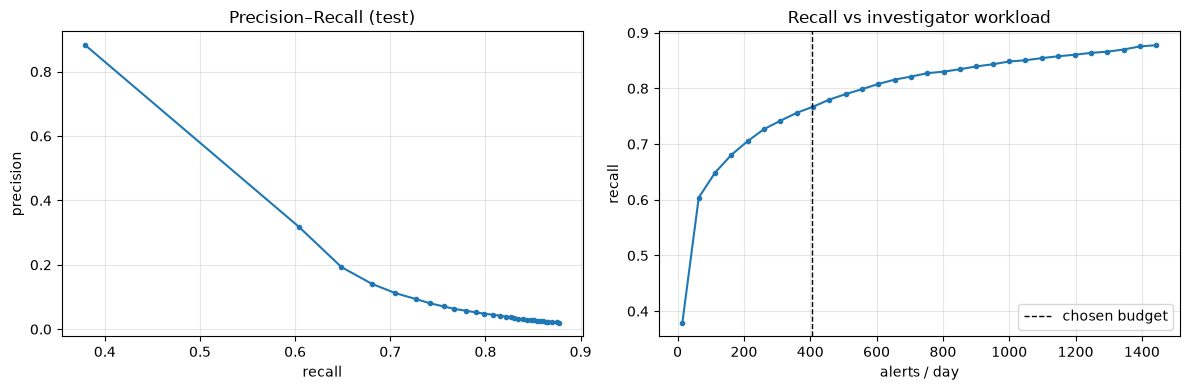

In [13]:
import numpy as np
import matplotlib.pyplot as plt

op = operating_points(test_scored, budgets=tuple(np.round(np.linspace(0.0005, 0.05, 30), 5)))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(op["recall"], op["precision"], marker=".")
ax[0].set(xlabel="recall", ylabel="precision", title="Precision–Recall (test)")
ax[1].plot(op["alerts_per_day"], op["recall"], marker=".")
ax[1].axvline(n_alert / n_days, ls="--", c="k", lw=1, label="chosen budget")
ax[1].set(xlabel="alerts / day", ylabel="recall", title="Recall vs investigator workload")
ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()

## 9. Test-set summary

| | value |
|---|---|
| Test PR-AUC | **0.54** (val 0.68 — see Part 2: the model decays over ~2 months) |
| Test ROC-AUC | 0.98 |
| Operating point (threshold fixed on val at 1% budget, applied to test) | **405 alerts/day · precision 6.4% · recall 77%** (realised alert rate 1.4%) |
| By-budget curve (threshold re-set on test) | 1% budget → 289/day · 8.6% · 74%;  0.1% → 29/day · 57% · 49% |
| Strong typologies | Smurfing 100%, Cash_Withdrawal 97%, Structuring 79% |
| Weak typologies | Fan_Out 60%, Layered_Fan_Out 63% — pure graph-structure patterns, no graph features yet |

**The trade-off, in one sentence:** with the threshold fixed on validation and
applied blind to test, ≈405 alerts/day (≈26 of them real) catches roughly
three-quarters of laundering; tightening the budget to 0.1% (29 alerts/day) raises
precision to 57% but drops recall to 49%. The right point is a capacity +
risk-appetite decision for the investigations team, and it is a threshold move —
the model does not change.

**Known limitations (feed Part 4):**
- No graph features -> weaker on fan-out / bipartite typologies.
- Val -> test PR-AUC drop of 0.14 -> retraining cadence matters (Part 2).
- Labels are synthetic and instantaneous; real SAR outcomes lag by months.